In [25]:
import os, sys, shutil
import pandas as pd
from tqdm.notebook import tqdm

In [3]:
sys.path.append("../training_data")

In [4]:
from utils.new_pdbs import Cif, Pdb

# dynamicPDB data

Assuming that the chain is the `auth_asym_id`.

In [5]:
csv = pd.read_csv("dynamicPDB_PDB_ID.csv")
csv

,pdb_name,seq_len
0,16pk_A,415
1,1a62_A,130
2,1ab1_A,46
3,1ah7_A,245
4,1ail_A,73
...,...,...
13629,8u97,214
13630,8ucx,159
13631,8wf7,157
13632,9abp,306


In [6]:
len(csv) == len(csv.pdb_name.unique())

True

In [7]:
# Unique PDBs (not chains; multiple may be independently simulated) vs total sims
len(set(p.split("_")[0] for p in csv.pdb_name.unique())), len(csv)

(13624, 13634)

In [8]:
dpdb = csv.pdb_name.unique().tolist()

## What about pdb_name without _chain?

Looks like they will only have a single polypeptide chain.

In [6]:
[p for p in csv.pdb_name.unique() if "_" not in p]

['102l',
 '102m',
 '103l',
 '104m',
 '106m',
 '107l',
 '108l',
 '109l',
 '109m',
 '110l',
 '110m',
 '111l',
 '111m',
 '112l',
 '113l',
 '114l',
 '115l',
 '118l',
 '119l',
 '120l',
 '122l',
 '123l',
 '125l',
 '126l',
 '127l',
 '128l',
 '129l',
 '130l',
 '131l',
 '132l',
 '133l',
 '134l',
 '135l',
 '138l',
 '141l',
 '142l',
 '143l',
 '145l',
 '146l',
 '147l',
 '152l',
 '153l',
 '155l',
 '156l',
 '157l',
 '158l',
 '159l',
 '160l',
 '161l',
 '162l',
 '163l',
 '164l',
 '165l',
 '166l',
 '172l',
 '173l',
 '181l',
 '182l',
 '183l',
 '184l',
 '185l',
 '186l',
 '187l',
 '188l',
 '190l',
 '191l',
 '192l',
 '193l',
 '194l',
 '195l',
 '198l',
 '199l',
 '1a2j',
 '1a2t',
 '1a2u',
 '1a4v',
 '1a53',
 '1a5p',
 '1a6g',
 '1a6k',
 '1a6m',
 '1a6n',
 '1a70',
 '1a76',
 '1a77',
 '1a7d',
 '1a7e',
 '1a8a',
 '1a8b',
 '1a8e',
 '1a8p',
 '1aa2',
 '1aac',
 '1aba',
 '1abf',
 '1abs',
 '1acf',
 '1ad2',
 '1ads',
 '1aec',
 '1agi',
 '1agy',
 '1ahc',
 '1ahr',
 '1aim',
 '1aj0',
 '1aj2',
 '1ajg',
 '1ajh',
 '1ajz',
 '1ak1',
 

# Extra test set

In [12]:
features = pd.read_pickle("../training_data/7.Extra_set/features.pkl")
print(len(features))
features

9


{'7gqu':     Residues                                                          \
          pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
 0       7gqu               1             A           12            A   
 1       7gqu               1             A           13            A   
 2       7gqu               1             A           14            A   
 3       7gqu               1             A           15            A   
 4       7gqu               1             A           16            A   
 ..       ...             ...           ...          ...          ...   
 414     7gqu               1             A          426            A   
 415     7gqu               1             A          427            A   
 416     7gqu               1             A          428            A   
 417     7gqu               1             A          429            A   
 418     7gqu               1             A          430            A   
 
                                   Label 

## How many PDBs are in the extra test set?

May not be the relevant chain.

In [10]:
dpdb_nochain = set(p.split("_")[0] for p in dpdb)

In [14]:
[i for i in features if i in dpdb_nochain]

[]

## Process

In [15]:
Cif.path = "../training_data/7.Extra_set/cifs"
Cif.original_cifs_path = "../training_data/7.Extra_set/origcifs"

In [16]:
ets = {
    (pdb, cif.residues.label_asym_id.unique().item()): {
        u: ures
        for u, ures in cif.residues.groupby("pdbx_sifts_xref_db_acc", sort=False)
        if u != "?"
    }
    for pdb in features
    for cif in (Cif(pdb),)
    
}

ets

{('7gqu',
  'A'): {'Q14191':      label_comp_id label_asym_id label_entity_id label_seq_id  \
  0              PHE             A               1           12   
  11             LEU             A               1           13   
  19             TRP             A               1           14   
  33             PRO             A               1           15   
  40             ALA             A               1           16   
  ...            ...           ...             ...          ...   
  3299           SER             A               1          426   
  3305           ARG             A               1          427   
  3316           LEU             A               1          428   
  3324           ASP             A               1          429   
  3332           HIS             A               1          430   
  
       pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
  0                    ?         527          PHE            A   
  11                   ?         5

In [17]:
{k: (len(v), tuple(len(r) for r in v.values())) for k, v in ets.items()}

{('7gqu', 'A'): (1, (419,)),
 ('7yg5', 'A'): (1, (1319,)),
 ('8aq6', 'G'): (1, (169,)),
 ('8f4s', 'A'): (1, (298,)),
 ('8jp0', 'A'): (1, (719,)),
 ('8qni', 'A'): (1, (377,)),
 ('8uk6', 'A'): (1, (573,)),
 ('8v81', 'A'): (1, (1132,)),
 ('9dnm', 'C'): (2, (329, 106))}

### 9dnm

**9dnm is a chimera with a cytochrome for crystallization**

In [18]:
ets[("9dnm", "C")].keys()

dict_keys(['P29066', 'P0ABE7'])

In [19]:
ets[("9dnm", "C")].pop('P0ABE7')
ets[("9dnm", "C")].keys()

dict_keys(['P29066'])

In [20]:
tuple((k, u) for k, v in ets.items() for u in v)

((('7gqu', 'A'), 'Q14191'),
 (('7yg5', 'A'), 'Q15878'),
 (('8aq6', 'G'), 'Q9GV45'),
 (('8f4s', 'A'), 'P0DTD1'),
 (('8jp0', 'A'), 'P32418-2'),
 (('8qni', 'A'), 'Q13191'),
 (('8uk6', 'A'), 'A0A1D8PQM9'),
 (('8v81', 'A'), 'P13569'),
 (('9dnm', 'C'), 'P29066'))

### 8jp0

**In the RCSB PDB 8jp0 is associated to P32418**, which was also force to successfully find apo structures.

In [21]:
ets[('8jp0', 'A')] = {'P32418': ets.pop(('8jp0', 'A'))['P32418-2']}

In [22]:
ets[('8jp0', 'A')]['P32418'].replace(to_replace={"pdbx_sifts_xref_db_acc": "P32418-2"}, value="P32418", inplace=True)
ets[('8jp0', 'A')]['P32418']

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,GLY,A,1,51,?,51,GLY,A,1,51,UNP,P32418,51,G
4,SER,A,1,52,?,52,SER,A,1,52,UNP,P32418,52,S
10,TYR,A,1,53,?,53,TYR,A,1,53,UNP,P32418,53,Y
22,TYR,A,1,54,?,54,TYR,A,1,54,UNP,P32418,54,Y
34,CYS,A,1,55,?,55,CYS,A,1,55,UNP,P32418,55,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5613,HIS,A,1,933,?,933,HIS,A,1,933,UNP,P32418,933,H
5623,ILE,A,1,934,?,934,ILE,A,1,934,UNP,P32418,934,I
5631,LYS,A,1,935,?,935,LYS,A,1,935,UNP,P32418,935,K
5640,GLY,A,1,936,?,936,GLY,A,1,936,UNP,P32418,936,G


In [23]:
tuple((k, u) for k, v in ets.items() for u in v)

((('7gqu', 'A'), 'Q14191'),
 (('7yg5', 'A'), 'Q15878'),
 (('8aq6', 'G'), 'Q9GV45'),
 (('8f4s', 'A'), 'P0DTD1'),
 (('8qni', 'A'), 'Q13191'),
 (('8uk6', 'A'), 'A0A1D8PQM9'),
 (('8v81', 'A'), 'P13569'),
 (('9dnm', 'C'), 'P29066'),
 (('8jp0', 'A'), 'P32418'))

In [33]:
ets_ups = tuple(u for k, v in ets.items() for u in v)
ets_ups

('Q14191',
 'Q15878',
 'Q9GV45',
 'P0DTD1',
 'Q13191',
 'A0A1D8PQM9',
 'P13569',
 'P29066',
 'P32418')

# dynamicPDB

## Process

In [34]:
Cif.path = "/data/fnerin/dpdbcifs"
Cif.original_cifs_path = "/data/fnerin/dpdbcifs"

In [35]:
matches = []

for i in tqdm(dpdb):
    pdb = i.split("_")[0]
    cif = Cif(pdb, filename=f"/data/fnerin/dpdbcifs/{pdb}_updated.cif.gz")
    if len(i.split("_")) > 1:
        chainres = cif.residues.query(f"""auth_asym_id == '{i.split("_")[-1]}'""")
    else:
        chainres = cif.residues
    if "pdbx_sifts_xref_db_acc" not in chainres.columns or not any(u in ets_ups for u in chainres.pdbx_sifts_xref_db_acc.unique()):
        continue
    else:
        matches.append(i)
        print(i)

  0%|          | 0/13634 [00:00<?, ?it/s]

6yhu_B
7buy_A
7k7p_B
2fby
2fc0
5rvj
5rvk
5rvl
5rvm
5rvn
5rvo
5rvp
5rvq
5rvr
5rvs
5rvt
5rvu
5rvv
5tf7
5tf8
5tfa
5tfb
5tfc
5tfd
5tff
5tfg
5tfi
5tfj
5tgk
6wcf
6wen
7bf4
7eq4
7jme
7kg3
7kqw
7kr0
7kr1
7kxb
7qch
7sgv
7sgw
7vsx
7xq6
8a4y
8a55
8ays
8az8
8crf
8crk
8crm
8hbl


In [36]:
matches = """6yhu_B
7buy_A
7k7p_B
2fby
2fc0
5rvj
5rvk
5rvl
5rvm
5rvn
5rvo
5rvp
5rvq
5rvr
5rvs
5rvt
5rvu
5rvv
5tf7
5tf8
5tfa
5tfb
5tfc
5tfd
5tff
5tfg
5tfi
5tfj
5tgk
6wcf
6wen
7bf4
7eq4
7jme
7kg3
7kqw
7kr0
7kr1
7kxb
7qch
7sgv
7sgw
7vsx
7xq6
8a4y
8a55
8ays
8az8
8crf
8crk
8crm
8hbl""".split("\n")

In [37]:
matches

['6yhu_B',
 '7buy_A',
 '7k7p_B',
 '2fby',
 '2fc0',
 '5rvj',
 '5rvk',
 '5rvl',
 '5rvm',
 '5rvn',
 '5rvo',
 '5rvp',
 '5rvq',
 '5rvr',
 '5rvs',
 '5rvt',
 '5rvu',
 '5rvv',
 '5tf7',
 '5tf8',
 '5tfa',
 '5tfb',
 '5tfc',
 '5tfd',
 '5tff',
 '5tfg',
 '5tfi',
 '5tfj',
 '5tgk',
 '6wcf',
 '6wen',
 '7bf4',
 '7eq4',
 '7jme',
 '7kg3',
 '7kqw',
 '7kr0',
 '7kr1',
 '7kxb',
 '7qch',
 '7sgv',
 '7sgw',
 '7vsx',
 '7xq6',
 '8a4y',
 '8a55',
 '8ays',
 '8az8',
 '8crf',
 '8crk',
 '8crm',
 '8hbl']

# OLD

## How many PDBs of dynamicPDB are in allodb?

May not be the relevant chain.

In [7]:
from src import *

In [8]:
db.init('database.db')

In [9]:
dpdb_nochain = set(p.split("_")[0] for p in dpdb)

In [10]:
sim_dpdb_nochain = [p.entry_id for p in PDB.select() if p.entry_id in dpdb_nochain]
len(sim_dpdb_nochain), sim_dpdb_nochain

(120,
 ['2pbk',
  '5bq1',
  '1pzo',
  '3fyh',
  '3pxf',
  '3pxz',
  '3pxq',
  '3hrf',
  '4a06',
  '4a07',
  '4aw1',
  '3jvr',
  '3jvs',
  '1wpu',
  '5krs',
  '2ica',
  '2o7n',
  '3m6f',
  '6b95',
  '4yi8',
  '1pzp',
  '5orl',
  '5ors',
  '5orv',
  '5orw',
  '5orx',
  '5ory',
  '5orz',
  '5os0',
  '5os1',
  '5os2',
  '5os3',
  '5os4',
  '5os5',
  '5osd',
  '5ose',
  '5osf',
  '6r4a',
  '2jfn',
  '3hv3',
  '3hv6',
  '3iw8',
  '3k3j',
  '3o8t',
  '3pg3',
  '2zfz',
  '5cc9',
  '5w3q',
  '4i4f',
  '3k8y',
  '5f6w',
  '5f6y',
  '6kx3',
  '4lyj',
  '5v9o',
  '6t5b',
  '6t5v',
  '6tam',
  '6tan',
  '2pip',
  '2pit',
  '2piv',
  '6d1y',
  '6d1z',
  '6nss',
  '4m0y',
  '4m13',
  '4m14',
  '4m15',
  '1t4g',
  '2fpm',
  '2y39',
  '4euv',
  '7nec',
  '1fxo',
  '1ig5',
  '1igv',
  '3ho6',
  '5c4t',
  '6sal',
  '6t4g',
  '6t4i',
  '6t4j',
  '6t4k',
  '6t4t',
  '6t4u',
  '6t4w',
  '6t4x',
  '6t4y',
  '6t50',
  '6tlq',
  '7np5',
  '7np6',
  '7npc',
  '5h13',
  '5ut4',
  '4ofg',
  '5o2d',
  '5v03',
  '5

## Download cifs

In [11]:
from src import utils
import os
from tqdm.notebook import tqdm

In [21]:
basedir = "/data/fnerin/dpdbcifs"
os.makedirs(basedir, exist_ok=True)

for pdb in tqdm(dpdb):
    pdb = pdb.split("_")[0]
    fn = f"/{basedir}/{pdb}_updated.cif.gz"
    if not os.path.isfile(fn):
        allodbcif = f"src/data/{pdb}_updated.cif.gz"
        mdatlascif = f"data/mdatlascifs/{pdb}.cif.gz"
        if os.path.isfile(allodbcif):
            os.system(f"cp {allodbcif} {fn}")
        elif os.path.isfile(mdatlascif):
            os.system(f"cp {mdatlascif} {fn}")
        else:
            with open(fn, "wb") as f:
                f.write(utils.PDBCif._download_SIFTS_cif(pdb))

  0%|          | 0/13634 [00:00<?, ?it/s]

## *Pdb class

Based on allodb's PDBCif and PDB classes to manage dynamicPDB' cif files as a Python object and access their information in the same way as in allodb.

In [12]:
import tempfile
from src.cifutils import MMCIF2Dict, CifFileWriter

class PDBCif:
    def __init__(self, pdb):
        self.filename = f"{basedir}/{pdb}_updated.cif.gz"
        self._name = pdb.upper()

    @property
    def data(self):
        return MMCIF2Dict().parse(self.filename)[self._name]

    def _get_or_save_text(self, filename=None, compress=False):
        # Establish how to get the file stream to write into
        if filename is not None:
            # If a file needs to be saved and a filename has been passed, check consistency and assess compression
            assert ( filename.endswith(".cif") or filename.endswith(".cif.gz") )
            if filename.endswith(".cif.gz"):
                compress = True
            file = lambda: open(filename, "w")
        elif filename is None:
            file = lambda: tempfile.NamedTemporaryFile("w+", suffix=".cif")

        # Open the established file stream and write the contents of the Cif as a .cif file
        with file() as f:
            writer = CifFileWriter(f.name, compress=compress)
            writer.write({self._name: self.data})
            # If filename is None/no saving is requested, return the contents of the .cif file as text string
            if filename is None:
                return f.file.read()

    @property
    def text(self):
        return self._get_or_save_text()

    def save(self, filename):
        return self._get_or_save_text(filename=filename)



class Pdb:
    def __init__(self, pdb):
        self.entry_id = pdb
    
    @property
    def cif(self):
        return PDBCif(self.entry_id)

    @property
    def atoms(self):
        return utils.pd.DF(self.cif.data["_atom_site"], dtype=str)

    @property
    def residues(self):
        return (
            self.atoms.drop(
                [
                    'group_PDB', 'id', 'type_symbol',
                    'auth_atom_id', 'label_atom_id', 'label_alt_id',
                    'Cartn_x', 'Cartn_y', 'Cartn_z',
                    'occupancy', 'B_iso_or_equiv', 'pdbx_formal_charge'
                ],
                axis=1
            )
            .drop_duplicates()
        )

    @property
    def _entities(self):
        return (
            utils.pd.DF(self.cif.data["_entity_poly"], dtype=str)
        )

    @property
    def _protein_entities(self):
        return (
            self._entities
            .query("type == 'polypeptide(L)'")
            .entity_id.to_list()
        )    

# Process

In [13]:
def get_protein_label_asym_ids(chain_res, pdb):
    "Get the id and residues of each label_asym_id of the passed anno. chain (auth_asym_id)'s residues that corresponds to a protein"
    return dict(
        (label_asym_id, label_asym_id_res)
            for label_asym_id in chain_res.label_asym_id.unique()
                for label_asym_id_res in [
                    pdb.residues.query(f"label_asym_id == '{label_asym_id}'")
                ]
                    if (
                        label_asym_id_res
                        .label_entity_id.unique().squeeze() 
                        in pdb._protein_entities
                    )
    )

def get_uniprots(res):
    "Get the Uniprot id and info (residues DataFrame, min and max) for each Uniprot in the passed residues"
    return {
        u: {
            "res": ures,
            "min": n.min(),
            "max": n.max(),
                     
        }  
            for u, ures in res.groupby("pdbx_sifts_xref_db_acc")
                if u != "?"
                    for n in [ures.pdbx_sifts_xref_db_num.astype(int),] 
    }


def get_uniprot_monomer_sites(u):
    "Get all monomer sites with info (label_entity_id, label_asym_id, and the results of get_uniprots function for the label_asym_id' residues)"
    for s in Site.raw(
f'''
SELECT Site.*
FROM Site, json_each(Site.info, '$.interacting_chains_info')
WHERE json_extract(json_each.value, '$.Uniprot') LIKE '%{u}%'
'''
    ):
        entities = [
            c
            for c in s.info["interacting_chains_info"]
                if c["polymer_type"] == "polypeptide(L)" 
        ]
        if len(entities) > 1: continue
            
        label_asym_id = s.nonredundant_site.protein_residues.label_asym_id.unique().tolist() # not homomer (only 1 polypeptidic interacting entity AND chain)
        if len(label_asym_id) > 1: continue
    
        yield (s, entities[0]["label_entity_id"], label_asym_id[0], get_uniprots(s.pdb.residues.query(f"label_asym_id == '{label_asym_id[0]}'")))
        

In [14]:
import pymol2

def get_chain_ligands(pdb, label_asym_id, threshold=4):
    sele = f"{label_asym_id}///*"

    with pymol2.PyMOL() as pymol:
        pymol.cmd.feedback(
            "disable", "executive", "details"
        )  # to silence "ExecutiveLoad-Detail: Detected mmCIF"
        pymol.cmd.load(pdb.cif.filename)

        # Retrieve all atoms within the threshold of the modulator selection
        atoms = pymol.cmd.get_model(f"(br. all within {threshold} of {sele}) and not {sele}")
        
    # Process the atom selection to obtain residue identifiers
    residue_ids = set(
        tuple(
            (
                a.segi, a.chain, a.resn,
                a.resi_number, a.ins_code or '?' # pdbx_PDB_ins_code or "?" if none
            ) 
            for a in atoms.atom
        )
    )

    # Transform the PyMOL-derived residue identifiers into a standard table of residues that can be used to retrieve the rows/residues from the parent structure's .residues table
    residues = pdb.residues.merge(
        pd.DataFrame(
            residue_ids,
            columns=[
                "label_asym_id", "auth_asym_id", "auth_comp_id",
                "auth_seq_id", "pdbx_PDB_ins_code"
            ],
            dtype=str
        )
    ).query("auth_comp_id != 'HOH'")

    # If there are any residues
    if len(residues) > 0:
        # Get the cif field with entity data        
        edata = pd.DataFrame(pdb.cif.data["_entity"], dtype=str)

        # Get dictionaries of the info of only non-polymer items
        ligands = [
            e
            for e in (
                edata
                .query(f"id in {residues.label_entity_id.unique().tolist()} and type == 'non-polymer'")[
                    ["id", "pdbx_description", "formula_weight"]
                ].to_dict("records")
            )
        ]

        # If there are any non-polymer items, return the dictionary with info
        if len(ligands) > 0:
            return {
                ("dpdb", "ions"): [e for e in ligands if "ion" in e["pdbx_description"].lower()],
                ("dpdb", "ligands"): [e for e in ligands if "ion" not in e["pdbx_description"].lower()]
            }

In [15]:
import numpy as np

In [16]:
warnings = {}

def get_matches(p):
    split = p.split("_")
    pdb = Pdb(split[0])
    
    if len(split) == 2:
        c = split[1]
        # sc: chain exists and is an auth_asym_id
        assert c in pdb.residues.auth_asym_id.unique()
        
    elif len(split) == 1: #assuming there will be only 1 polypeptidic chain
        c = pdb.residues.query(f"label_entity_id in {pdb._protein_entities}").auth_asym_id.drop_duplicates().item() # will fail if there's more than 1 chain
    
    # Get the residues of the annotated chain
    cres = pdb.residues.query(f"auth_asym_id == '{c}'")
    
    # Get the residues of each label_asym_id of the anno. chain that corresponds to a protein
    prot_label_asym_ids = get_protein_label_asym_ids(cres, pdb)
    # sc: at least there has to be one protein; but it would be weird if there's more than 1
    assert len(prot_label_asym_ids) > 0
    if len(prot_label_asym_ids) > 1: 
        warnings[p] = f"{p} has more than 1 protein label_asym_ids ({prot_label_asym_ids.keys()}) in the chain {c}"
        print(warnings[p])

    # For each protein label_asym_id, if it has a Uniprot annotation
    for prot_label_asym_id, prot_label_asym_id_res in prot_label_asym_ids.items():        
        if "pdbx_sifts_xref_db_name" in prot_label_asym_id_res:

            ligands = get_chain_ligands(pdb, prot_label_asym_id)
            
            # Get the dictionaries of information of the Uniprots present in it; expected 1
            ups = get_uniprots(prot_label_asym_id_res)
            if len(ups) > 1: 
                warnings[p] = f"{p} has more than 1 Uniprots in the chain {c} (label_asym_id {prot_label_asym_id}): {list(ups.keys())}"
                print(warnings[p])

            # For each Uniprot present in the label_asym_id
            for u, uinfo in ups.items():
                # Start a dictionary with base information about the chain and Uniprot
                d = {
                    ("dpdb", "p"): p,
                    ("dpdb", "pdb"): pdb.entry_id,
                    ("dpdb", "auth_asym_id"): c,
                    ("dpdb", "label_asym_id"): prot_label_asym_id,
                    ("dpdb", "label_entity_id"): prot_label_asym_id_res.label_entity_id.unique().squeeze(),
                    ("dpdb", "uniprot"): u,
                    ("dpdb", "u_min"): uinfo["min"],
                    ("dpdb", "u_max"): uinfo["max"],
                    # ("dpdb", "u_len"): uinfo["len"], ####### ?
                }
                d.update(ligands or {})
                
                # Get the sites of allodb that contain the present Uniprot id and the dictionaries of information of them
                sites = get_uniprot_monomer_sites(u)
                urange = range(uinfo["min"], uinfo["max"]+1)

                # For each site match (monomers or homomers)
                for s, slabel_entity_id, slabel_asym_id, sites_uniprots in sites:
                    # And for each Uniprot found in the site
                    for su, suinfo in sites_uniprots.items():
                        surange = range(suinfo["min"], suinfo["max"]+1)
                        minmax = len(np.intersect1d(urange, surange))
                        
                        merge = len(
                            uinfo["res"]
                            .merge(
                                suinfo["res"],
                                on = ["pdbx_sifts_xref_db_name", "pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"],
                                how = "outer", indicator = True
                            ).query("_merge == 'both'")
                        )
                        
                        s = ({
                            ("allodb", "pdb"): s.pdb.entry_id,
                            ("allodb", "site_id"): s.id,
                            ("allodb", "label_entity_id"): slabel_entity_id,
                            ("allodb", "label_asym_id"): slabel_asym_id,
                            ("allodb", "uniprot"): u,
                            ("allodb", "u_min"): suinfo["min"],
                            ("allodb", "u_max"): suinfo["max"],
                            # ("allodb", "u_len"): uinfo["len"], ####### ?
                        
                            ("overlap_minmax", "atlas_in_allodb"): minmax/len(urange),
                            ("overlap_minmax", "allodb_in_atlas"): minmax/len(surange),
                            ("overlap_merge", "atlas_in_allodb"): merge/len(uinfo["res"]),
                            ("overlap_merge", "allodb_in_atlas"): merge/len(suinfo["res"]),
                        })
                        
                        sd = d.copy()
                        sd.update(s)
                        yield sd

In [17]:
import pandas as pd
from tqdm.notebook import tqdm

In [27]:
# processed = []
matches = pd.DataFrame()
errors = []

In [22]:
for p in dpdb:#tqdm(dpdb, smoothing=0):
    if p not in processed:
        try:
            match = pd.DataFrame(get_matches(p))
        except:
            errors.append(p)
            continue
    
        if len(match) > 0:
            matches = pd.concat([
                matches,
                match
            ])
        processed.append(p)

In [26]:
match

""


In [28]:
import pickle

with open("data/dpdb_processed_list.pkl", "wb") as f:
    pickle.dump(processed, f)

In [29]:
with open("data/dpdb_errors.pkl", "wb") as f:
    pickle.dump(errors, f)

In [7]:
matches.to_pickle("data/dpdb_processed_dpdb.pkl")

In [30]:
import pickle

with open("data/dpdb_processed_list.pkl", "rb") as f:
    processed = pickle.load(f)

print(processed)

['16pk_A', '1a62_A', '1ab1_A', '1ah7_A', '1ail_A', '1aol_A', '1b2s_E', '1b2s_F', '1b8d_K', '1bgf_A', '1bkp_A', '1bq8_A', '1btk_A', '1bx7_A', '1bxy_A', '1by2_A', '1c1k_A', '1c52_A', '1chd_A', '1coj_A', '1cpq_A', '1ctf_A', '1cuo_A', '1d2t_A', '1d3y_B', '1d4t_A', '1dci_C', '1dd3_B', '1dfu_P', '1dj0_B', '1dk8_A', '1dlj_A', '1doi_A', '1dow_A', '1dpt_A', '1dtd_B', '1dvo_A', '1dwk_A', '1dzf_A', '1ear_A', '1ef1_D', '1egw_B', '1esw_A', '1ewf_A', '1ez3_B', '1f20_A', '1f3u_G', '1f9p_A', '1fcz_A', '1fd3_A', '1fk5_A', '1fm4_A', '1fn9_A', '1fs1_A', '1fx4_A', '1fxo_G', '1g2r_A', '1g38_A', '1g6g_A', '1gpj_A', '1gqe_A', '1gqv_A', '1h02_B', '1h2e_A', '1h8e_G', '1h99_A', '1hbn_E', '1hc9_B', '1hq0_A', '1huf_A', '1hw1_B', '1hye_A', '1i2t_A', '1i4m_A', '1ifg_A', '1ig0_B', '1ig3_A', '1ijt_A', '1ijx_C', '1ikt_A', '1im5_A', '1io1_A', '1iom_A', '1iuq_A', '1ix9_A', '1j0p_A', '1j2l_A', '1j5u_A', '1j77_A', '1j8e_A', '1j8r_A', '1jhs_A', '1jif_A', '1jke_C', '1jo0_A', '1jq5_A', '1juv_A', '1jwq_A', '1jyo_B', '1jyo_F',

In [31]:
with open("data/dpdb_errors.pkl", "rb") as f:
    errors = pickle.load(f)

errors

[]

In [20]:
df = pd.read_pickle("data/dpdb_processed_dpdb.pkl")
df

,"(dpdb, p)","(dpdb, pdb)","(dpdb, auth_asym_id)","(dpdb, label_asym_id)","(dpdb, label_entity_id)","(dpdb, uniprot)","(dpdb, u_min)","(dpdb, u_max)","(dpdb, ions)","(dpdb, ligands)",...,"(allodb, site_id)","(allodb, label_entity_id)","(allodb, label_asym_id)","(allodb, uniprot)","(allodb, u_min)","(allodb, u_max)","(overlap_minmax, atlas_in_allodb)","(overlap_minmax, allodb_in_atlas)","(overlap_merge, atlas_in_allodb)","(overlap_merge, allodb_in_atlas)"
0,1btk_A,1btk,A,A,1,Q06187,2,170,"[{'id': '2', 'pdbx_description': 'ZINC ION', '...",[],...,62,1,A,Q06187,276,379,0.000000,0.000000,0.000000,0.000000
1,1btk_A,1btk,A,A,1,Q06187,2,170,"[{'id': '2', 'pdbx_description': 'ZINC ION', '...",[],...,5674,1,A,Q06187,393,657,0.000000,0.000000,0.000000,0.000000
2,1btk_A,1btk,A,A,1,Q06187,2,170,"[{'id': '2', 'pdbx_description': 'ZINC ION', '...",[],...,5722,1,A,Q06187,392,659,0.000000,0.000000,0.000000,0.000000
3,1btk_A,1btk,A,A,1,Q06187,2,170,"[{'id': '2', 'pdbx_description': 'ZINC ION', '...",[],...,5723,1,A,Q06187,395,659,0.000000,0.000000,0.000000,0.000000
0,1fxo_G,1fxo,G,G,1,Q9HU22,1,293,"[{'id': '2', 'pdbx_description': 'SULFATE ION'...","[{'id': '3', 'pdbx_description': 'THYMIDINE-5'...",...,3453,1,A,Q9HU22,2,293,0.996587,1.000000,0.996587,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,8wf7,8wf7,A,A,1,P12497,1204,1358,"[{'id': '2', 'pdbx_description': 'SULFATE ION'...",[],...,2448,1,A,P12497,1203,1356,0.987097,0.993506,0.914474,0.985816
25,8wf7,8wf7,A,A,1,P12497,1204,1358,"[{'id': '2', 'pdbx_description': 'SULFATE ION'...",[],...,2449,1,A,P12497,1203,1356,0.987097,0.993506,0.921053,0.992908
26,8wf7,8wf7,A,A,1,P12497,1204,1358,"[{'id': '2', 'pdbx_description': 'SULFATE ION'...",[],...,2450,1,A,P12497,1202,1356,0.987097,0.987097,0.914474,0.985816
27,8wf7,8wf7,A,A,1,P12497,1204,1358,"[{'id': '2', 'pdbx_description': 'SULFATE ION'...",[],...,2451,1,A,P12497,1203,1356,0.987097,0.993506,0.934211,0.993007


In [32]:
df.columns = pd.MultiIndex.from_tuples(df.columns)
df

dpdb                                                                 \
         p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
0   1btk_A  1btk            A             A               1  Q06187     2   
1   1btk_A  1btk            A             A               1  Q06187     2   
2   1btk_A  1btk            A             A               1  Q06187     2   
3   1btk_A  1btk            A             A               1  Q06187     2   
0   1fxo_G  1fxo            G             G               1  Q9HU22     1   
..     ...   ...          ...           ...             ...     ...   ...   
24    8wf7  8wf7            A             A               1  P12497  1204   
25    8wf7  8wf7            A             A               1  P12497  1204   
26    8wf7  8wf7            A             A               1  P12497  1204   
27    8wf7  8wf7            A             A               1  P12497  1204   
28    8wf7  8wf7            A             A               1  P12497  1204   

                                                             \
   u_max                                               ions   
0    170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
1    170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
2    170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
3    170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
0    293  [{'id': '2', 'pdbx_description': 'SULFATE ION'...   
..   ...                                                ...   
24  1358  [{'id': '2', 'pdbx_description': 'SULFATE ION'...   
25  1358  [{'id': '2', 'pdbx_description': 'SULFATE ION'...   
26  1358  [{'id': '2', 'pdbx_description': 'SULFATE ION'...   
27  1358  [{'id': '2', 'pdbx_description': 'SULFATE ION'...   
28  1358  [{'id': '2', 'pdbx_description': 'SULFATE ION'...   

                                                       ...  allodb  \
                                              ligands  ... site_id   
0                                                  []  ...      62   
1                                                  []  ...    5674   
2                                                  []  ...    5722   
3                                                  []  ...    5723   
0   [{'id': '3', 'pdbx_description': 'THYMIDINE-5'...  ...    3453   
..                                                ...  ...     ...   
24                                                 []  ...    2448   
25                                                 []  ...    2449   
26                                                 []  ...    2450   
27                                                 []  ...    2451   
28                                                 []  ...    4189   

                                                      overlap_minmax  \
   label_entity_id label_asym_id uniprot u_min u_max atlas_in_allodb   
0                1             A  Q06187   276   379        0.000000   
1                1             A  Q06187   393   657        0.000000   
2                1             A  Q06187   392   659        0.000000   
3                1             A  Q06187   395   659        0.000000   
0                1             A  Q9HU22     2   293        0.996587   
..             ...           ...     ...   ...   ...             ...   
24               1             A  P12497  1203  1356        0.987097   
25               1             A  P12497  1203  1356        0.987097   
26               1             A  P12497  1202  1356        0.987097   
27               1             A  P12497  1203  1356        0.987097   
28               1             A  P12497  1204  1354        0.974194   

                     overlap_merge                  
   allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0         0.000000        0.000000        0.000000  
1         0.000000        0.000000        0.000000  
2         0.000000        0.000000        0.000000  
3         0.000000        0.000000        0.000000  
0         1.000000

In [17]:
# df = df.set_index([("dpdb", "pdb"), ("dpdb", "auth_asym_id"), ("dpdb", "uniprot"), ("allodb", "pdb"), ("allodb", "site_id"), ("allodb", "uniprot")], drop=False)
# df

# Analysis

## Overlap of PDBs in both dynamicPDB and allodb

In [35]:
df[
    df[("dpdb", "pdb")] == df[("allodb", "pdb")]
].drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                 \
         p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
0   2pbk_B  2pbk            B             B               1  O36607     3   
0   2y39_A  2y39            A             A               1  P37975    39   
0     1ig5  1ig5            A             A               1  P02633     5   
1     1igv  1igv            A             A               1  P02633     5   
0     1pzo  1pzo            A             A               1  P62593    24   
..     ...   ...          ...           ...             ...     ...   ...   
8     6zwr  6zwr            A             A               1  P47811     5   
1     7nec  7nec            A             A               1  P51449   266   
22    7np5  7np5            A             A               1  P51449   266   
23    7np6  7np6            A             A               1  P51449   266   
24    7npc  7npc            A             A               1  P51449   268   

         allodb                                                            \
   u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
0    230   2pbk      56               1             B  O36607     3   230   
0    148   2y39    3326               1             A  P37975    39   148   
0     79   1ig5    3675               1             A  P02633     5    79   
1     79   1igv    3676               1             A  P02633     5    79   
0    286   1pzo     383               1             A  P62593    24   286   
..   ...    ...     ...             ...           ...     ...   ...   ...   
8    353   6zwr    4437               1             A  P47811     5   353   
1    507   7nec    3402               1             A  P51449   266   507   
22   507   7np5    3938               1             A  P51449   266   507   
23   507   7np6    3939               1             A  P51449   266   507   
24   507   7npc    3940               1             A  P51449   268   507   

    overlap_minmax                   overlap_merge                  
   atlas_in_allodb allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0              1.0             1.0             1.0             1.0  
0              1.0             1.0             1.0             1.0  
0              1.0             1.0             1.0             1.0  
1              1.0             1.0             1.0             1.0  
0              1.0             1.0             1.0             1.0  
..             ...             ...             ...             ...  
8              1.0             1.0             1.0             1.0  
1              1.0             1.0             1.0             1.0  
22             1.0             1.0             1.0             1.0  
23             1.0             1.0             1.0             1.0  
24             1.0             1.0             1.0             1.0  

[120 rows x 19 columns]

120 PDBs/sites are both in allodb and dynamicPDB.

<br>

In [36]:
# also match the simulated label_asym_id besides the PDB
df[
    (df[("dpdb", "pdb")] == df[("allodb", "pdb")]) \
    & (df[("dpdb", "label_asym_id")] == df[("allodb", "label_asym_id")])
].drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                 \
         p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
0   2pbk_B  2pbk            B             B               1  O36607     3   
0   2y39_A  2y39            A             A               1  P37975    39   
0     1ig5  1ig5            A             A               1  P02633     5   
1     1igv  1igv            A             A               1  P02633     5   
0     1pzo  1pzo            A             A               1  P62593    24   
..     ...   ...          ...           ...             ...     ...   ...   
8     6zwr  6zwr            A             A               1  P47811     5   
1     7nec  7nec            A             A               1  P51449   266   
22    7np5  7np5            A             A               1  P51449   266   
23    7np6  7np6            A             A               1  P51449   266   
24    7npc  7npc            A             A               1  P51449   268   

         allodb                                                            \
   u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
0    230   2pbk      56               1             B  O36607     3   230   
0    148   2y39    3326               1             A  P37975    39   148   
0     79   1ig5    3675               1             A  P02633     5    79   
1     79   1igv    3676               1             A  P02633     5    79   
0    286   1pzo     383               1             A  P62593    24   286   
..   ...    ...     ...             ...           ...     ...   ...   ...   
8    353   6zwr    4437               1             A  P47811     5   353   
1    507   7nec    3402               1             A  P51449   266   507   
22   507   7np5    3938               1             A  P51449   266   507   
23   507   7np6    3939               1             A  P51449   266   507   
24   507   7npc    3940               1             A  P51449   268   507   

    overlap_minmax                   overlap_merge                  
   atlas_in_allodb allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0              1.0             1.0             1.0             1.0  
0              1.0             1.0             1.0             1.0  
0              1.0             1.0             1.0             1.0  
1              1.0             1.0             1.0             1.0  
0              1.0             1.0             1.0             1.0  
..             ...             ...             ...             ...  
8              1.0             1.0             1.0             1.0  
1              1.0             1.0             1.0             1.0  
22             1.0             1.0             1.0             1.0  
23             1.0             1.0             1.0             1.0  
24             1.0             1.0             1.0             1.0  

[120 rows x 19 columns]

And all 120 have the chain from allodb (only monomer sites) simulated.

<br>

## Chimeras

In [40]:
# dynamicPDB entries with multiple Uniprots and that have been matches to different separately
temp = (
    df[
        [("dpdb", "pdb"), ("dpdb", "uniprot")]
    ].drop_duplicates()
    .duplicated(("dpdb", "pdb"))
)

any(temp), temp

(False,
 0    False
 0    False
 0    False
 0    False
 0    False
      ...  
 0    False
 0    False
 0    False
 0    False
 0    False
 Length: 918, dtype: bool)

There are no PDBs of dynamicPDB in the df for which two Uniprots have been identified (and then at least one match in allodb has been found for both). However, it still should be checked whether among the pdbs analyzed in the dataframe there are chimeras.

<br>

In [42]:
# dynamicPDB pdbs-chains that are chimeras (independently of the matched Uniprots)
for i, (p, c) in tqdm(
    df[
        [("dpdb", "pdb"), ("dpdb", "label_asym_id")]
    ].drop_duplicates()
    .iterrows()
):
    pdb = Pdb(p)
    cres = pdb.residues.query(f"label_asym_id == '{c}'")
    
    if "pdbx_sifts_xref_db_name" in cres:
        ups = get_uniprots(cres)
        if len(ups) > 1:
            print("Chimera:", p, c, ups.keys())

0it [00:00, ?it/s]

Chimera: 3t92 A dict_keys(['Q09472', 'Q15744'])
Chimera: 3hc8 A dict_keys(['O76074', 'P27815'])
Chimera: 5vb3 A dict_keys(['P51449', 'Q15596'])
Chimera: 6w9h A dict_keys(['P51449', 'Q15788'])
Chimera: 6w9i A dict_keys(['P51449', 'Q15788'])
Chimera: 7kxd A dict_keys(['P51449', 'Q15788'])
Chimera: 7xuw A dict_keys(['P27694', 'P54132'])


In [48]:
chimeras = df.loc[
[i in ["3t92", "3hc8", "5vb3", "6w9h", "6w9i", "7kxd", "7xuw"] for i in df[("dpdb", "pdb")]]
]

chimeras.drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                 \
         p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
0   3t92_A  3t92            A             A               1  Q09472  1729   
1   3t92_A  3t92            A             A               1  Q09472  1729   
0     3hc8  3hc8            A             A               1  O76074   536   
0     5vb3  5vb3            A             A               1  P51449   265   
1     5vb3  5vb3            A             A               1  P51449   265   
..     ...   ...          ...           ...             ...     ...   ...   
21    7kxd  7kxd            A             A               1  P51449   265   
22    7kxd  7kxd            A             A               1  P51449   265   
23    7kxd  7kxd            A             A               1  P51449   265   
24    7kxd  7kxd            A             A               1  P51449   265   
0     7xuw  7xuw            A             A               1  P54132   550   

         allodb                                                            \
   u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
0   1818   6pf1    3989               1             A  Q09472  1287  1661   
1   1818   6pgu    3990               1             A  Q09472  1287  1662   
0    858   1tbf    2050               1             A  O76074   534   858   
0    507   4ypq     273               1             A  P51449   265   507   
1    507   7nec    3402               1             A  P51449   266   507   
..   ...    ...     ...             ...           ...     ...   ...   ...   
21   507   6ucg    3937               1             A  P51449   267   507   
22   507   7np5    3938               1             A  P51449   266   507   
23   507   7np6    3939               1             A  P51449   266   507   
24   507   7npc    3940               1             A  P51449   268   507   
0    564   7aud    3502               1             F  P54132   640  1288   

    overlap_minmax                   overlap_merge                  
   atlas_in_allodb allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0         0.000000        0.000000        0.000000        0.000000  
1         0.000000        0.000000        0.000000        0.000000  
0         1.000000        0.993846        1.000000        0.916923  
0         1.000000        1.000000        1.000000        1.000000  
1         0.995885        1.000000        0.995885        1.000000  
..             ...             ...             ...             ...  
21        0.991770        1.000000        0.991770        1.000000  
22        0.995885        1.000000        0.995885        1.000000  
23        0.995885        1.000000        0.995885        1.000000  
24        0.987654        1.000000        0.987654        1.000000  
0         0.000000        0.000000        0.000000        0.000000  

[104 rows x 19 columns]

In [50]:
chimeras[[("dpdb", "pdb"), ("dpdb", "uniprot")]].drop_duplicates()#.duplicated(("dpdb", "pdb"))

dpdb        
    pdb uniprot
0  3t92  Q09472
0  3hc8  O76074
0  5vb3  P51449
0  6w9h  P51449
0  6w9i  P51449
0  7kxd  P51449
0  7xuw  P54132

There are many chimeras simulated in dynamicPDB that have a Uniprot match on allodb, however for each of the PDBs only one of the Uniprots of the chimera is always found and not the other.

<br>

In [58]:
# matches of these chimeras with considerable overlap of the simulated portion of the Uniprot with the part in allodb
chimeras[chimeras[["overlap_minmax", "overlap_merge"]].max(axis=1) > 0].drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                       \
       p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min u_max   
0   3hc8  3hc8            A             A               1  O76074   536   858   
0   5vb3  5vb3            A             A               1  P51449   265   507   
1   5vb3  5vb3            A             A               1  P51449   265   507   
2   5vb3  5vb3            A             A               1  P51449   265   507   
3   5vb3  5vb3            A             A               1  P51449   265   507   
..   ...   ...          ...           ...             ...     ...   ...   ...   
20  7kxd  7kxd            A             A               1  P51449   265   507   
21  7kxd  7kxd            A             A               1  P51449   265   507   
22  7kxd  7kxd            A             A               1  P51449   265   507   
23  7kxd  7kxd            A             A               1  P51449   265   507   
24  7kxd  7kxd            A             A               1  P51449   265   507   

   allodb                                                            \
      pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
0    1tbf    2050               1             A  O76074   534   858   
0    4ypq     273               1             A  P51449   265   507   
1    7nec    3402               1             A  P51449   266   507   
2    5c4o    3918               1             A  P51449   267   507   
3    5c4s    3919               1             A  P51449   267   507   
..    ...     ...             ...           ...     ...   ...   ...   
20   6tlt    3936               1             A  P51449   268   507   
21   6ucg    3937               1             A  P51449   267   507   
22   7np5    3938               1             A  P51449   266   507   
23   7np6    3939               1             A  P51449   266   507   
24   7npc    3940               1             A  P51449   268   507   

    overlap_minmax                   overlap_merge                  
   atlas_in_allodb allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0         1.000000        0.993846        1.000000        0.916923  
0         1.000000        1.000000        1.000000        1.000000  
1         0.995885        1.000000        0.995885        1.000000  
2         0.991770        1.000000        0.991770        1.000000  
3         0.991770        1.000000        0.991770        1.000000  
..             ...             ...             ...             ...  
20        0.987654        1.000000        0.987654        1.000000  
21        0.991770        1.000000        0.991770        1.000000  
22        0.995885        1.000000        0.995885        1.000000  
23        0.995885        1.000000        0.995885        1.000000  
24        0.987654        1.000000        0.987654        1.000000  

[101 rows x 19 columns]

And in a majority of the cases (101/120), there is >0 overlap between the part of the Uniprot simulated and the one in allodb.

<br>

In [81]:
# original df with "merged-out" entries of the chimeras' matches
df_nochimeras = (
    df.merge(
        chimeras, 
        how="outer", 
        on=[("dpdb", "pdb"), ("allodb", "pdb"), ("allodb", "label_asym_id")], 
        indicator=True, 
        suffixes=[None, "_del"]
    ).loc[lambda x: x["_merge"] != 'both']
    .loc[:, lambda x: [i for i in x.columns if not i[0].endswith("_del")]]
    .drop(columns="_merge")
)
df_nochimeras.drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                 \
          p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
0      1aq1  1aq1            A             A               1  P24941     1   
1      1aq1  1aq1            A             A               1  P24941     1   
2      1aq1  1aq1            A             A               1  P24941     1   
3      1aq1  1aq1            A             A               1  P24941     1   
4      1aq1  1aq1            A             A               1  P24941     1   
...     ...   ...          ...           ...             ...     ...   ...   
10942  8wf7  8wf7            A             A               1  P12497  1204   
10943  8wf7  8wf7            A             A               1  P12497  1204   
10944  8wf7  8wf7            A             A               1  P12497  1204   
10945  8wf7  8wf7            A             A               1  P12497  1204   
10946  8wf7  8wf7            A             A               1  P12497  1204   

            allodb                                                            \
      u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
0       298   3pxf     523               1             A  P24941     1   298   
1       298   3pxq     530               1             A  P24941     1   298   
2       298   3pxz     526               1             A  P24941     1   298   
3       298   3py1     529               1             A  P24941     1   298   
4       298   4ez7     585               1             A  P24941     1   298   
...     ...    ...     ...             ...           ...     ...   ...   ...   
10942  1358   5krs    1902               1             A  P12497  1204  1354   
10943  1358   5krt    1903               1             A  P12497  1204  1354   
10944  1358   6lmi    2450               1             A  P12497  1202  1356   
10945  1358   6lmq    2451               1             A  P12497  1203  1356   
10946  1358   7ke0    4189               1             A  P12497  1204  1354   

       overlap_minmax                   overlap_merge                  
      atlas_in_allodb allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0            1.000000        1.000000        1.000000        0.929530  
1            1.000000        1.000000        1.000000        0.942177  
2            1.000000        1.000000        1.000000        0.929530  
3            1.000000        1.000000        1.000000        0.929530  
4            1.000000        1.000000        1.000000        0.929530  
...               ...             ...             ...             ...  
10942        0.974194        1.000000        0.953947        0.993151  
10943        0.974194        1.000000        0.940789        0.993056  
10944        0.987097        0.987097        0.914474        0.985816  
10945        0.987097        0.993506        0.934211        0.993007  
10946        0.974194        1.000000        0.868421        1.000000  

[10843 rows x 19 columns]

In [75]:
# other dynamicPDB pdbs (from the merged-out df) that have a match with the allodb pdbs that have been matched with a dynamicPDB-chimera
df_nochimeras.merge(
    chimeras[[("allodb", "pdb"), ("allodb", "label_asym_id")]].drop_duplicates()
)

dpdb                                                                 \
        p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
0    1xp0  1xp0            A             A               1  O76074   534   
1    3tge  3tge            A             A               1  O76074   536   
2    3tgg  3tgg            A             A               1  O76074   536   
3    4md6  4md6            A             A               1  O76074   535   
4    4ymq  4ymq            A             A               1  P51449   265   
..    ...   ...          ...           ...             ...     ...   ...   
554  7npc  7npc            A             A               1  P51449   268   
555  7npc  7npc            A             A               1  P51449   268   
556  7npc  7npc            A             A               1  P51449   268   
557  7npc  7npc            A             A               1  P51449   268   
558  7npc  7npc            A             A               1  P51449   268   

                                                              \
    u_max                                               ions   
0     858  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
1     858  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
2     858  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
3     860  [{'id': '2', 'pdbx_description': 'SULFATE ION'...   
4     507  [{'id': '2', 'pdbx_description': 'SODIUM ION',...   
..    ...                                                ...   
554   507                                                 []   
555   507                                                 []   
556   507                                                 []   
557   507                                                 []   
558   507                                                 []   

                                                        ...  allodb  \
                                               ligands  ... site_id   
0    [{'id': '4', 'pdbx_description': '2-{2-ETHOXY-...  ...    2050   
1    [{'id': '4', 'pdbx_description': '7-(6-methoxy...  ...    2050   
2    [{'id': '4', 'pdbx_description': '7-(6-methoxy...  ...    2050   
3    [{'id': '3', 'pdbx_description': '3-(4-hydroxy...  ...    2050   
4    [{'id': '3', 'pdbx_description': 'GLYCEROL', '...  ...     273   
..                                                 ...  ...     ...   
554  [{'id': '2', 'pdbx_description': '4-[[3-[2-chl...  ...    3937   
555  [{'id': '2', 'pdbx_description': '4-[[3-[2-chl...  ...    3402   
556  [{'id': '2', 'pdbx_description': '4-[[3-[2-chl...  ...    3938   
557  [{'id': '2', 'pdbx_description': '4-[[3-[2-chl...  ...    3939   
558  [{'id': '2', 'pdbx_description': '4-[[3-[2-chl...  ...    3940   

                                                       overlap_minmax  \
    label_entity_id label_asym_id uniprot u_min u_max atlas_in_allodb   
0                 1             A  O76074   534   858        1.000000   
1                 1             A  O76074   534   858        1.000000   
2                 1             A  O76074   534   858        1.000000   
3                 1             A  O76074   534   858        0.993865   
4                 1             A  P51449   265   507        1.000000   
..              ...           ...     ...   ...   ...             ...   
554               1             A  P51449   267   507        1.000000   
555               1             A  P51449   266   507        1.000000   
556               1             A  P51449   266   507        1.000000   
557               1             A  P51449   266   507        1.000000   
558               1             A  P51449   268   507        1.000000   

                      overlap_merge                  
    allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0          1.000000        1.000000        1.000000  
1          0.993846        1.000000        0.993846  
2          0.993846        1.000000        0.987692  
3          0.996923        0.993311    

In [93]:
# which of the allodb pdbs that have been matched with a dynamicPDB-chimera have a considerable match with any of the non-chimera dynamicPDBs
{
    # dictionary with True/False if the pdb-chain has a considerable match
    tuple(i): i in (
        # from the merged-out df, select only the matches of the relevant allodb pdbs
        df_nochimeras.merge(
            chimeras[[("allodb", "pdb"), ("allodb", "label_asym_id")]].drop_duplicates()
        )[ # select only considerable matches
            df_nochimeras.merge(
                chimeras[[("allodb", "pdb"), ("allodb", "label_asym_id")]].drop_duplicates()
            )[["overlap_minmax", "overlap_merge"]].max(axis=1) > 0.9
        ][ # and make a list/numpy array of the remaining allodb pdb-chains to check whether the iterated pdb-chain is in this list
            [("allodb", "pdb"), ("allodb", "label_asym_id")]
        ].drop_duplicates()
        .values
    )
    # for each allodb pdb-chain
    for i in chimeras[[("allodb", "pdb"), ("allodb", "label_asym_id")]].drop_duplicates().values
}

{('6pf1', 'A'): True,
 ('6pgu', 'A'): True,
 ('1tbf', 'A'): True,
 ('4ypq', 'A'): True,
 ('7nec', 'A'): True,
 ('5c4o', 'A'): True,
 ('5c4s', 'A'): True,
 ('5c4t', 'A'): True,
 ('5c4u', 'A'): True,
 ('5lwp', 'A'): True,
 ('6sal', 'A'): True,
 ('6t4g', 'A'): True,
 ('6t4i', 'A'): True,
 ('6t4j', 'A'): True,
 ('6t4k', 'A'): True,
 ('6t4t', 'A'): True,
 ('6t4u', 'A'): True,
 ('6t4w', 'A'): True,
 ('6t4x', 'A'): True,
 ('6t4y', 'A'): True,
 ('6t50', 'A'): True,
 ('6tlm', 'A'): True,
 ('6tlq', 'A'): True,
 ('6tlt', 'A'): True,
 ('6ucg', 'A'): True,
 ('7np5', 'A'): True,
 ('7np6', 'A'): True,
 ('7npc', 'A'): True,
 ('7aud', 'F'): False}

In [86]:
chimeras[
    (chimeras[[("allodb", "pdb"), ("allodb", "label_asym_id")]].values == ('7aud', 'F')).any(axis=1)
].drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                       \
      p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min u_max   
0  7xuw  7xuw            A             A               1  P54132   550   564   

  allodb                                                            \
     pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
0   7aud    3502               1             F  P54132   640  1288   

   overlap_minmax                   overlap_merge                  
  atlas_in_allodb allodb_in_atlas atlas_in_allodb allodb_in_atlas  
0             0.0             0.0             0.0             0.0

The only allodb chain/site that doesn't have a match (e.g., its Uniprot is simulated) in a non-chimera dynamicPDB simulation doesn't have overlap with the simulated portion of the Uniprot. So, dropping dynamicPDB-chimeras does not result in loss of information, as the rest of allodb entries matched with these chimeras do have a considerable match with other simulations.

<br>

In [88]:
old_df = df
df = df_nochimeras
len(old_df), len(df)

(10947, 10843)

## Overlap

In [89]:
overlaps = [('overlap_minmax', 'atlas_in_allodb'),
            ('overlap_minmax', 'allodb_in_atlas'),
            ( 'overlap_merge', 'atlas_in_allodb'),
            ( 'overlap_merge', 'allodb_in_atlas')]

df.sort_values(overlaps)

dpdb                                                                 \
            p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
24     1btk_A  1btk            A             A               1  Q06187     2   
25     1btk_A  1btk            A             A               1  Q06187     2   
26     1btk_A  1btk            A             A               1  Q06187     2   
27     1btk_A  1btk            A             A               1  Q06187     2   
797      1rni  1rni            A             A               1  Q54324    40   
...       ...   ...          ...           ...             ...     ...   ...   
10690    8elx  8elx            A             A               1  P01112     1   
10708    8ely  8ely            A             A               1  P01112     1   
10726    8elz  8elz            A             A               1  P01112     1   
10761    8fg3  8fg3            A             A               1  P01112     1   
10779    8fg4  8fg4            A             A               1  P01112     1   

                                                                \
      u_max                                               ions   
24      170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
25      170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
26      170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
27      170  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
797     249  [{'id': '2', 'pdbx_description': 'ZINC ION', '...   
...     ...                                                ...   
10690   166  [{'id': '3', 'pdbx_description': 'CALCIUM ION'...   
10708   166  [{'id': '2', 'pdbx_description': 'MAGNESIUM IO...   
10726   166  [{'id': '3', 'pdbx_description': 'MAGNESIUM IO...   
10761   166  [{'id': '3', 'pdbx_description': 'MAGNESIUM IO...   
10779   166  [{'id': '3', 'pdbx_description': 'CALCIUM ION'...   

                                                          ...  allodb  \
                                                 ligands  ... site_id   
24                                                    []  ...    5674   
25                                                    []  ...      62   
26                                                    []  ...    5722   
27                                                    []  ...    5723   
797                                                   []  ...    5469   
...                                                  ...  ...     ...   
10690  [{'id': '2', 'pdbx_description': 'PHOSPHOAMINO...  ...    2951   
10708  [{'id': '3', 'pdbx_description': 'PHOSPHOAMINO...  ...    2951   
10726  [{'id': '2', 'pdbx_description': 'PHOSPHOAMINO...  ...    2951   
10761  [{'id': '2', 'pdbx_description': 'PHOSPHOAMINO...  ...    2951   
10779  [{'id': '2', 'pdbx_description': 'PHOSPHOAMINO...  ...    2951   

                                                         overlap_minmax  \
      label_entity_id label_asym_id uniprot u_min u_max atlas_in_allodb   
24                  1             A  Q06187   393   657             0.0   
25                  1             A  Q06187   276   379             0.0   
26                  1             A  Q06187   392   659             0.0   
27                  1             A  Q06187   395   659             0.0   
797                 2             B  Q54324   256   370             0.0   
...               ...           ...     ...   ...   ...             ...   
10690               1             A  P01112     1   166             1.0   
10708               1             A  P01112     1   166             1.0   
10726               1             A  P01112     1   166             1.0   
10761               1             A  P01112     1   166             1.0   
10779               1             A  P01112     1   166             1.0   

                        overlap_merge                  
      allodb_in_atlas atlas_in_allodb allodb_in_atlas  
24                0.0             0.0             0.0  
25             

In [94]:
# dropping all entries that don't show any match at all
temp = df[
    ~(df[overlaps].mean(axis=1) == 0)
].sort_values(overlaps)

temp.drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                 \
          p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
2401   3eg2  3eg2            A             A               1  P00519    60   
2406   3eg3  3eg3            A             A               1  P00519    60   
5442   4jjd  4jjd            A             A               1  P00519    60   
5437   4jjc  4jjc            A             A               1  P00519    64   
3244   3m1m  3m1m            A             A               1  Q54324    40   
...     ...   ...          ...           ...             ...     ...   ...   
10690  8elx  8elx            A             A               1  P01112     1   
10708  8ely  8ely            A             A               1  P01112     1   
10726  8elz  8elz            A             A               1  P01112     1   
10761  8fg3  8fg3            A             A               1  P01112     1   
10779  8fg4  8fg4            A             A               1  P01112     1   

            allodb                                                            \
      u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
2401    121   5dc4      19               1             A  P00519   121   220   
2406    121   5dc4      19               1             A  P00519   121   220   
5442    121   5dc4      19               1             A  P00519   121   220   
5437    121   5dc4      19               1             A  P00519   121   220   
3244    370   6gvt    5469               2             B  Q54324   256   370   
...     ...    ...     ...             ...           ...     ...   ...   ...   
10690   166   5zc6    2951               1             A  P01112     1   166   
10708   166   5zc6    2951               1             A  P01112     1   166   
10726   166   5zc6    2951               1             A  P01112     1   166   
10761   166   5zc6    2951               1             A  P01112     1   166   
10779   166   5zc6    2951               1             A  P01112     1   166   

       overlap_minmax                   overlap_merge                  
      atlas_in_allodb allodb_in_atlas atlas_in_allodb allodb_in_atlas  
2401         0.016129            0.01        0.016129        0.010000  
2406         0.016129            0.01        0.016129        0.010000  
5442         0.016129            0.01        0.017241        0.010000  
5437         0.017241            0.01        0.017241        0.010000  
3244         0.347432            1.00        6.875000        0.956522  
...               ...             ...             ...             ...  
10690        1.000000            1.00       15.000000        1.000000  
10708        1.000000            1.00       15.000000        1.000000  
10726        1.000000            1.00       15.000000        1.000000  
10761        1.000000            1.00       15.000000        1.000000  
10779        1.000000            1.00       15.000000        1.000000  

[10203 rows x 19 columns]

array([[<Axes: title={'center': "('overlap_minmax', 'atlas_in_allodb')"}>,
        <Axes: title={'center': "('overlap_minmax', 'allodb_in_atlas')"}>],
       [<Axes: title={'center': "('overlap_merge', 'atlas_in_allodb')"}>,
        <Axes: title={'center': "('overlap_merge', 'allodb_in_atlas')"}>]],
      dtype=object)

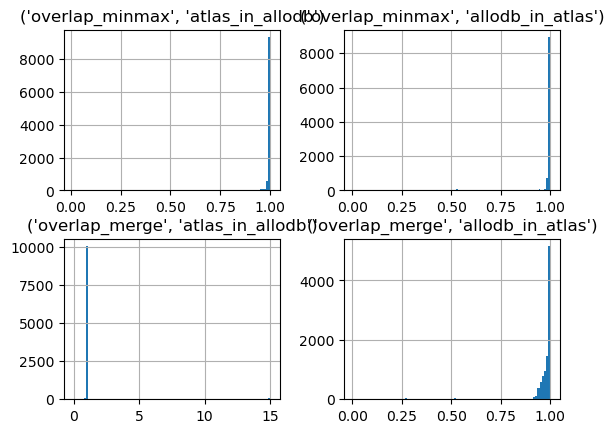

In [97]:
temp[overlaps].hist(bins=100)

In [99]:
temp[:30].drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])

dpdb                                                                 \
           p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
2401    3eg2  3eg2            A             A               1  P00519    60   
2406    3eg3  3eg3            A             A               1  P00519    60   
5442    4jjd  4jjd            A             A               1  P00519    60   
5437    4jjc  4jjc            A             A               1  P00519    64   
3244    3m1m  3m1m            A             A               1  Q54324    40   
4760    4d86  4d86            A             A               1  Q460N5   791   
8031  5ws1_A  5ws1            A             A               1  P09874   662   
1620    2fpm  2fpm            A             A               1  O73948     5   
1654    2i1q  2i1q            A             A               1  O73948     5   
829     1t4g  1t4g            A             A               1  O73948     5   
2696    3fyh  3fyh            A             A               1  O73948     5   
1702  2pbk_B  2pbk            B             B               1  O36607     3   
5783    4wkq  4wkq            A             A               1  P00533   696   
5794    4wrg  4wrg            A             A               1  P00533   696   
5778    4wkq  4wkq            A             A               1  P00533   696   
5789    4wrg  4wrg            A             A               1  P00533   696   
5784    4wkq  4wkq            A             A               1  P00533   696   
5795    4wrg  4wrg            A             A               1  P00533   696   
4543    3w2s  3w2s            A             A               1  P00533   701   
4565    3w33  3w33            A             A               1  P00533   701   
4554    3w32  3w32            A             A               1  P00533   701   
3631    3poz  3poz            A             A               1  P00533   701   
4544    3w2s  3w2s            A             A               1  P00533   701   
4538    3w2s  3w2s            A             A               1  P00533   701   
2072    2rgp  2rgp            A             A               1  P00533   702   
4566    3w33  3w33            A             A               1  P00533   701   
4560    3w33  3w33            A             A               1  P00533   701   
4555    3w32  3w32            A             A               1  P00533   701   
3632    3poz  3poz            A             A               1  P00533   701   
4549    3w32  3w32            A             A               1  P00533   701   

           allodb                                                            \
     u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
2401   121   5dc4      19               1             A  P00519   121   220   
2406   121   5dc4      19               1             A  P00519   121   220   
5442   121   5dc4      19               1             A  P00519   121   220   
5437   121   5dc4      19               1             A  P00519   121   220   
3244   370   6gvt    5469               2             B  Q54324   256   370   
4760  1191   5o2d    4084               1             A  Q460N5  1002  1190   
8031  1011   6bhv    4230               1             A  P09874   789  1010   
1620   322   2gdj    3322               1             A  O73948    63   322   
1654   322   2gdj    3322               1             A  O73948    63   322   
829    322   2gdj    3322               1             A  O73948    63   322   
2696   322   2gdj    3322               1             A  O73948    63   322   
1702   230   4p3h    4869               1             B  O36607     4   196   
5783  1020   6z4b    1202               1             A  P00533   700   982   
5794  1019   6z4b    1202               1             A  P00533   700   982   
5778  1020   5zwj    5673               1             A  P00533   702   985   
5789  1019   5zwj    5673               1             A  P00533   702   985   
5784  1020   7a2a    1203               1             A  

In [108]:
# sorting by the minimum overlap among the 4 overlap% columns
temp.loc[temp[overlaps].min(axis=1).sort_values().index].drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])[:30]

dpdb                                                                 \
            p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
2401     3eg2  3eg2            A             A               1  P00519    60   
2406     3eg3  3eg3            A             A               1  P00519    60   
5442     4jjd  4jjd            A             A               1  P00519    60   
5437     4jjc  4jjc            A             A               1  P00519    64   
2184   2yvq_A  2yvq            A             A               1  P31327  1343   
2186   2yvq_A  2yvq            A             A               1  P31327  1343   
2185   2yvq_A  2yvq            A             A               1  P31327  1343   
5439     4jjd  4jjd            A             A               1  P00519    60   
10186    7pw2  7pw2            A             A               1  P00519    63   
5443     4jjd  4jjd            A             A               1  P00519    60   
10182    7pw2  7pw2            A             A               1  P00519    63   
10165    7pvv  7pvv            A             A               1  P00519    64   
5429     4jjb  4jjb            A             A               1  P00519    64   
5433     4jjb  4jjb            A             A               1  P00519    64   
10169    7pvv  7pvv            A             A               1  P00519    64   
10164    7pvr  7pvr            A             A               1  P00519    63   
5421     4j9b  4j9b            A             A               1  P00519    63   
10160    7pvr  7pvr            A             A               1  P00519    63   
5434     4jjc  4jjc            A             A               1  P00519    64   
5417     4j9b  4j9b            A             A               1  P00519    63   
2402     3eg2  3eg2            A             A               1  P00519    60   
5438     4jjc  4jjc            A             A               1  P00519    64   
2407     3eg3  3eg3            A             A               1  P00519    60   
2403     3eg3  3eg3            A             A               1  P00519    60   
2398     3eg2  3eg2            A             A               1  P00519    60   
8424     6o1b  6o1b            A             A               1  Q6SZW1   562   
8423     6o1b  6o1b            A             A               1  Q6SZW1   562   
9915     7myx  7myx            A             A               1  P31749     3   
855      1unr  1unr            A             A               1  P31749     3   
9914     7myx  7myx            A             A               1  P31749     3   

            allodb                                                            \
      u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
2401    121   5dc4      19               1             A  P00519   121   220   
2406    121   5dc4      19               1             A  P00519   121   220   
5442    121   5dc4      19               1             A  P00519   121   220   
5437    121   5dc4      19               1             A  P00519   121   220   
2184   1478   5dou    3164               1             B  P31327    43  1493   
2186   1478   6w2j    3165               1             A  P31327    43  1496   
2185   1478   6uel     228               1             A  P31327    43  1492   
5439    121   1opl    2405               1             A  P00519    62   512   
10186   119   5mo4    5640               1             A  P00519    64   512   
5443    121   5mo4    5640               1             A  P00519    64   512   
10182   119   1opl    2405               1             A  P00519    62   512   
10165   120   1opl    2405               1             A  P00519    62   512   
5429    120   1opl    2405               1             A  P00519    62   512   
5433    120   5mo4    5640               1             A  P00519    64   512   
10169   120   5mo4    5640               1             A  P00519    64   512   
10164   120   5mo4    5640               1             A  P00519    64   512   
5421    

There are cases where the simulated portion of the Uniprot is either much bigger or much smaller than the relevant region in the allodb structure, so a minimum threshold is to be set.

<br>

<Axes: >

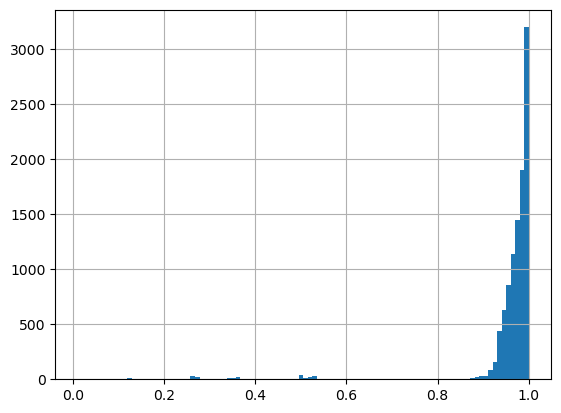

In [117]:
temp[overlaps].min(axis=1).hist(bins=100)

In [119]:
filtered_temp = temp[ temp[overlaps].min(axis=1) > 0.8 ]

filtered_temp.loc[filtered_temp[overlaps].min(axis=1).sort_values().index].drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])[:30]

dpdb                                                                 \
            p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
1702   2pbk_B  2pbk            B             B               1  O36607     3   
4555     3w32  3w32            A             A               1  P00533   701   
4549     3w32  3w32            A             A               1  P00533   701   
4554     3w32  3w32            A             A               1  P00533   701   
10936    8wf7  8wf7            A             A               1  P12497  1204   
4544     3w2s  3w2s            A             A               1  P00533   701   
10946    8wf7  8wf7            A             A               1  P12497  1204   
4538     3w2s  3w2s            A             A               1  P00533   701   
5783     4wkq  4wkq            A             A               1  P00533   696   
5794     4wrg  4wrg            A             A               1  P00533   696   
3626     3poz  3poz            A             A               1  P00533   701   
3632     3poz  3poz            A             A               1  P00533   701   
5778     4wkq  4wkq            A             A               1  P00533   696   
5784     4wkq  4wkq            A             A               1  P00533   696   
5789     4wrg  4wrg            A             A               1  P00533   696   
5781     4wkq  4wkq            A             A               1  P00533   696   
4566     3w33  3w33            A             A               1  P00533   701   
4543     3w2s  3w2s            A             A               1  P00533   701   
5795     4wrg  4wrg            A             A               1  P00533   696   
4560     3w33  3w33            A             A               1  P00533   701   
5790     4wrg  4wrg            A             A               1  P00533   696   
5663     4pmp  4pmp            A             A               1  P04629   501   
3631     3poz  3poz            A             A               1  P00533   701   
5791     4wrg  4wrg            A             A               1  P00533   696   
5792     4wrg  4wrg            A             A               1  P00533   696   
5796     4wrg  4wrg            A             A               1  P00533   696   
5788     4wrg  4wrg            A             A               1  P00533   696   
4565     3w33  3w33            A             A               1  P00533   701   
10941    8wf7  8wf7            A             A               1  P12497  1204   
10940    8wf7  8wf7            A             A               1  P12497  1204   

            allodb                                                            \
      u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
1702    230   4p3h    4869               1             B  O36607     4   196   
4555   1017   7a2a    1203               1             A  P00533   700   984   
4549   1017   5zwj    5673               1             A  P00533   702   985   
4554   1017   6z4b    1202               1             A  P00533   700   982   
10936  1358   4lh5    1898               1             A  P12497  1204  1355   
4544   1019   7a2a    1203               1             A  P00533   700   984   
10946  1358   7ke0    4189               1             A  P12497  1204  1354   
4538   1019   5zwj    5673               1             A  P00533   702   985   
5783   1020   6z4b    1202               1             A  P00533   700   982   
5794   1019   6z4b    1202               1             A  P00533   700   982   
3626   1017   5zwj    5673               1             A  P00533   702   985   
3632   1017   7a2a    1203               1             A  P00533   700   984   
5778   1020   5zwj    5673               1             A  P00533   702   985   
5784   1020   7a2a    1203               1             A  P00533   700   984   
5789   1019   5zwj    5673               1             A  P00533   702   985   
5781   1020   6p1l    5708               1             A  P00533   701  1007   
4566   1

In [131]:
(filtered_temp[("dpdb", "pdb")] == filtered_temp[("allodb", "pdb")]).sum()

120

In [132]:
sum(
    j[0] == j[1]
    for j in zip(
        (tuple(i) for i in filtered_temp[[("dpdb", "pdb"), ("dpdb", "label_asym_id")]].values),
        (tuple(i) for i in filtered_temp[[("allodb", "pdb"), ("allodb", "label_asym_id")]].values)
    )
)

120

The 120 PDBs of dynamicPDB that were as-is in allodb are retained up to this step.

<br>

In [134]:
# list of unique dynamicPDBs-chains that are directly as-is in allodb
to_drop = set(
    j[0]
    for j in zip(
        (tuple(i) for i in filtered_temp[[("dpdb", "pdb"), ("dpdb", "label_asym_id")]].values),
        (tuple(i) for i in filtered_temp[[("allodb", "pdb"), ("allodb", "label_asym_id")]].values)
    )
    if j[0] == j[1]
)
print(to_drop)

{('6tam', 'A'), ('1ig5', 'A'), ('5ory', 'A'), ('6zwr', 'A'), ('5var', 'A'), ('5kmi', 'A'), ('6t4i', 'A'), ('1igv', 'A'), ('4m14', 'A'), ('5osd', 'A'), ('6t4j', 'A'), ('6nss', 'A'), ('4eh5', 'A'), ('4euv', 'A'), ('5krs', 'A'), ('6t4k', 'A'), ('6x3n', 'A'), ('5f6w', 'A'), ('5os2', 'A'), ('6qdz', 'A'), ('5orv', 'A'), ('4lyj', 'A'), ('4yi8', 'A'), ('5bq1', 'A'), ('5ors', 'A'), ('4a07', 'A'), ('5v9o', 'A'), ('1t4g', 'A'), ('3hrf', 'A'), ('5osf', 'A'), ('3hv3', 'A'), ('6qe1', 'A'), ('6bkw', 'A'), ('6t4x', 'A'), ('4m0y', 'A'), ('6tan', 'A'), ('5orl', 'A'), ('6y4t', 'A'), ('6t4t', 'A'), ('6d1y', 'A'), ('4eh2', 'A'), ('5w3q', 'A'), ('5o8v', 'A'), ('3pg3', 'A'), ('6ypk', 'A'), ('6r4a', 'A'), ('2fpm', 'A'), ('5f6y', 'A'), ('2piv', 'A'), ('6t4g', 'A'), ('2pbk', 'B'), ('6zwp', 'A'), ('5os3', 'A'), ('2pip', 'A'), ('5o8u', 'A'), ('6t5v', 'A'), ('2jfn', 'A'), ('2o7n', 'A'), ('6sal', 'A'), ('1pzo', 'A'), ('6t4u', 'A'), ('3pxq', 'A'), ('6b95', 'A'), ('3jvs', 'A'), ('5cc9', 'A'), ('4i4f', 'A'), ('5orw', 

In [142]:
direct = filtered_temp[[
    j[0] == j[1]
    for j in zip(
        (tuple(i) for i in filtered_temp[[("dpdb", "pdb"), ("dpdb", "label_asym_id")]].values),
        (tuple(i) for i in filtered_temp[[("allodb", "pdb"), ("allodb", "label_asym_id")]].values)
    )
]]
direct.drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")] + overlaps)[:30]

dpdb                                                                 \
           p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
475     1ig5  1ig5            A             A               1  P02633     5   
479     1igv  1igv            A             A               1  P02633     5   
747     1pzo  1pzo            A             A               1  P62593    24   
750     1pzp  1pzp            A             A               1  P62593    24   
825     1t4g  1t4g            A             A               1  O73948     5   
1619    2fpm  2fpm            A             A               1  O73948     5   
1659    2ica  2ica            A             A               1  P20701   154   
1664    2jfn  2jfn            A             A               1  P22634    20   
1667    2o7n  2o7n            A             A               1  P20701   154   
1701  2pbk_B  2pbk            B             B               1  O36607     3   
1705    2pip  2pip            L             A               1  P10275   671   
1706    2pip  2pip            L             A               1  P10275   671   
1729    2pit  2pit            A             A               1  P10275   670   
1753    2piv  2piv            A             A               1  P10275   671   
2180  2y39_A  2y39            A             A               1  P37975    39   
2697    3fyh  3fyh            A             A               1  O73948     5   
2698    3fyh  3fyh            A             A               1  O73948     5   
2732    3hrf  3hrf            A             A               1  O15530    75   
2774    3hv3  3hv3            A             A               1  Q16539     4   
2850    3hv6  3hv6            A             A               1  Q16539     4   
2949    3iw8  3iw8            A             A               1  Q16539     4   
2995    3jvr  3jvr            A             A               1  O14757     2   
2999    3jvs  3jvs            A             A               1  O14757     2   
3030    3k3j  3k3j            A             A               1  Q16539     5   
3074    3k8y  3k8y            A             A               1  P01112     1   
3249    3m6f  3m6f            A             A               1  P20701   154   
3430    3o8t  3o8t            A             A               1  Q16539     5   
3574    3pg3  3pg3            A             A               1  Q16539     4   
3636    3pxf  3pxf            A             A               1  P24941     1   
3648    3pxq  3pxq            A             A               1  P24941     1   

           allodb                                                            
     u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max  
475     79   1ig5    3675               1             A  P02633     5    79  
479     79   1igv    3676               1             A  P02633     5    79  
747    286   1pzo     383               1             A  P62593    24   286  
750    286   1pzp    2348               1             A  P62593    24   286  
825    322   1t4g    3318               1             A  O73948     5   322  
1619   322   2fpm    3321               1             A  O73948     5   322  
1659   331   2ica    1909               1             A  P20701   154   331  
1664   285   2jfn    2424               1             A  P22634    20   285  
1667   332   2o7n    1910               1             A  P20701   154   332  
1701   230   2pbk      56               1             B  O36607     3   230  
1705   919   2pip    3108               1             A  P10275   671   919  
1706   919   2pip    3109               1             A  P10275   671   919  
1729   919   2pit    3111               1             A  P10275   670   919  
1753   919   2piv    3115               1             A  P10275   671   919  
2180   148   2y39    3326               1             A  P37975    39   148  
2697   322   3fyh     520               1             A  O73948     5   322  
2698   322   3fyh    3323               1             A  O73948     5   322

In [143]:
nodirect = filtered_temp[[tuple(i) not in to_drop for i in filtered_temp[[("dpdb", "pdb"), ("dpdb", "label_asym_id")]].values]]

nodirect.drop(columns=[("dpdb", "ions"), ("dpdb", "ligands")])[:30]

dpdb                                                                 \
         p   pdb auth_asym_id label_asym_id label_entity_id uniprot u_min   
5783  4wkq  4wkq            A             A               1  P00533   696   
5794  4wrg  4wrg            A             A               1  P00533   696   
5778  4wkq  4wkq            A             A               1  P00533   696   
5789  4wrg  4wrg            A             A               1  P00533   696   
5784  4wkq  4wkq            A             A               1  P00533   696   
5795  4wrg  4wrg            A             A               1  P00533   696   
4543  3w2s  3w2s            A             A               1  P00533   701   
4565  3w33  3w33            A             A               1  P00533   701   
4554  3w32  3w32            A             A               1  P00533   701   
3631  3poz  3poz            A             A               1  P00533   701   
4544  3w2s  3w2s            A             A               1  P00533   701   
4538  3w2s  3w2s            A             A               1  P00533   701   
2072  2rgp  2rgp            A             A               1  P00533   702   
4566  3w33  3w33            A             A               1  P00533   701   
4560  3w33  3w33            A             A               1  P00533   701   
4555  3w32  3w32            A             A               1  P00533   701   
3632  3poz  3poz            A             A               1  P00533   701   
4549  3w32  3w32            A             A               1  P00533   701   
3626  3poz  3poz            A             A               1  P00533   701   
2073  2rgp  2rgp            A             A               1  P00533   702   
2067  2rgp  2rgp            A             A               1  P00533   702   
1611  2f4j  2f4j            A             A               1  P00519   227   
1610  2f4j  2f4j            A             A               1  P00519   227   
5779  4wkq  4wkq            A             A               1  P00533   696   
9751  7ken  7ken            A             A               1  P18031     2   
9752  7ken  7ken            A             A               1  P18031     2   
5697  4qap  4qap            A             A               1  P18031     1   
5698  4qap  4qap            A             A               1  P18031     1   
5706  4qbw  4qbw            A             A               1  P18031     1   
5707  4qbw  4qbw            A             A               1  P18031     1   

           allodb                                                            \
     u_max    pdb site_id label_entity_id label_asym_id uniprot u_min u_max   
5783  1020   6z4b    1202               1             A  P00533   700   982   
5794  1019   6z4b    1202               1             A  P00533   700   982   
5778  1020   5zwj    5673               1             A  P00533   702   985   
5789  1019   5zwj    5673               1             A  P00533   702   985   
5784  1020   7a2a    1203               1             A  P00533   700   984   
5795  1019   7a2a    1203               1             A  P00533   700   984   
4543  1019   6z4b    1202               1             A  P00533   700   982   
4565  1018   6z4b    1202               1             A  P00533   700   982   
4554  1017   6z4b    1202               1             A  P00533   700   982   
3631  1017   6z4b    1202               1             A  P00533   700   982   
4544  1019   7a2a    1203               1             A  P00533   700   984   
4538  1019   5zwj    5673               1             A  P00533   702   985   
2072  1016   6z4b    1202               1             A  P00533   700   982   
4566  1018   7a2a    1203               1             A  P00533   700   984   
4560  1018   5zwj    5673               1             A  P00533   702   985   
4555  1017   7a2a    1203               1             A  P00533   700   984   
3632  1017   7a2a    1203               1             A  P00533   700   984   
4549  1017   5zwj    5673               

In [146]:
len(direct), len(nodirect[[("dpdb", "pdb"), ("dpdb", "label_asym_id")]].drop_duplicates()), len(nodirect)

(120, 671, 7120)

There are a total of (120+671)=791 simulations of dynamicPDB of a protein-chain for which there is (at least) 1 site in allodb on a pdb of the same Uniprot of the protein, and which is on a monomeric site (1 chain in nonredundant_site_pdb; could be "symmetric" homomer in, e.g., the assembly).

<br>

In [160]:
with open("data/dpdb_direct.pkl", "wb") as f:
    pickle.dump(direct, f)

In [161]:
with open("data/dpdb_nodirect.pkl", "wb") as f:
    pickle.dump(nodirect, f)

### Similarity

In [153]:
seqs = {}

for i, (p, c, u) in (
    nodirect[
        [("dpdb", "pdb"), ("dpdb", "label_asym_id"), ("dpdb", "uniprot")]
    ].drop_duplicates()
    .iterrows()
):
    pdb = Pdb(p)
    seq = "".join(
        pdb.residues
        .query(f"label_asym_id == '{c}' and pdbx_sifts_xref_db_acc == '{u}'")
        .loc[:, "pdbx_sifts_xref_db_res"]
    ).replace("?", "")

    seqs[(p, u)] = seq
seqs

{('4wkq',
  'P00533'): 'GEAPNQALLRILKETEFKKIKVLGSGTVYKGLWIPEGEKVKIPVAIKESPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKVPIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWMIDADSRPKFRELIIEFSKMARDPQRYLVIQGDMDDVVDADEYLIPQ',
 ('4wrg',
  'P00533'): 'GEAPNQALLRILKETEFKKIKVLGTVYKGLWIPEGEKVKIPVAIKESPKNKEILDEAYVMASVDNPHVCRLLGICLTSVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEKVPIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWMIDADSRPKFRELIIEFSKMARDPQRYLVIQGDMDDVVDADEYLIP',
 ('3w2s',
  'P00533'): 'QALLRILKETEFKKIKVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLKVPIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWMIDADSRPKFRELIIEFSKMARDPQRYLVIQGDERMHLPSPTDSNFYRALMDEEDMDDVVDADEYLIP',
 ('3w33',
  'P00533'): 'QALLR

In [154]:
from biotite.sequence import LetterAlphabet, ProteinSequence

In [155]:
print(ProteinSequence.alphabet)

['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


In [156]:
# Forcing ProteinSequence objects to the 20 standard amino acid 1-letter codes
ProteinSequence.alphabet = LetterAlphabet(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y'])#, 'B', 'Z', 'X', '*'])

In [157]:
from biotite.sequence.align import align_optimal, SubstitutionMatrix
from biotite.sequence.align import get_sequence_identity

In [158]:
sims = {}

iterseqs = list(dict(seqs).items())

while len(iterseqs) > 0:
    (p, u), seq = iterseqs.pop()
    for (p2, u2), seq2 in iterseqs:
        sims[((p, u),(p2, u2))] = pd.DF(
            (
                (al.score, get_sequence_identity(al))
                for al in align_optimal(
                    ProteinSequence(seq),
                    ProteinSequence(seq2),
                    SubstitutionMatrix.std_protein_matrix(),
                    max_number=10
                )
            ),
            columns = ["aln_score", "seq_id"]
        ).mean().to_dict()

sims

{(('8dai', 'P0ABQ4'), ('4wkq', 'P00533')): {'aln_score': -1069.0,
  'seq_id': 0.20408163265306123},
 (('8dai', 'P0ABQ4'), ('4wrg', 'P00533')): {'aln_score': -1007.0,
  'seq_id': 0.17348136349664994},
 (('8dai', 'P0ABQ4'), ('3w2s', 'P00533')): {'aln_score': -1166.0,
  'seq_id': 0.19960045173952612},
 (('8dai', 'P0ABQ4'), ('3w33', 'P00533')): {'aln_score': -1081.0,
  'seq_id': 0.2063861229372647},
 (('8dai', 'P0ABQ4'), ('3w32', 'P00533')): {'aln_score': -1248.0,
  'seq_id': 0.2014676200618693},
 (('8dai', 'P0ABQ4'), ('3poz', 'P00533')): {'aln_score': -1028.0,
  'seq_id': 0.19743992199669436},
 (('8dai', 'P0ABQ4'), ('2rgp', 'P00533')): {'aln_score': -949.0,
  'seq_id': 0.19503546099290778},
 (('8dai', 'P0ABQ4'), ('2f4j', 'P00519')): {'aln_score': -983.0,
  'seq_id': 0.17832167832167833},
 (('8dai', 'P0ABQ4'), ('7ken', 'P18031')): {'aln_score': -1105.0,
  'seq_id': 0.1926600113742136},
 (('8dai', 'P0ABQ4'), ('4qap', 'P18031')): {'aln_score': -1113.0,
  'seq_id': 0.1879347991914996},
 (('8d

<Axes: >

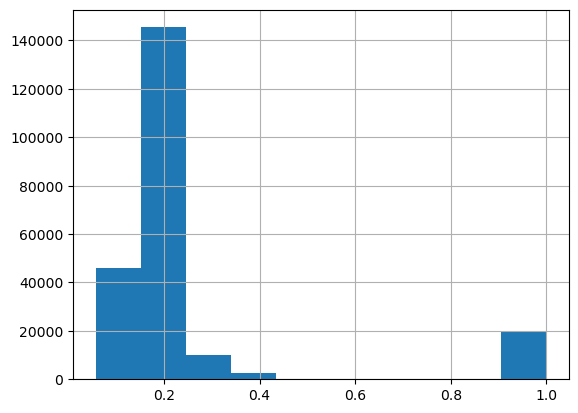

In [159]:
pd.Series([v['seq_id'] for v in sims.values()]).hist()

The final selected simulated proteins are very dissimilar between each other in terms of sequence.

<br>

# *Viz

In [97]:
text = Pdb("2y39").cif.text
text

'data_2Y39\n#\n_entry.id       2Y39\n\n#\nloop_\n_citation.id                            \n_citation.title                         \n_citation.journal_abbrev                \n_citation.journal_volume                \n_citation.page_first                    \n_citation.page_last                     \n_citation.year                          \n_citation.journal_id_ASTM               \n_citation.country                       \n_citation.journal_id_ISSN               \n_citation.journal_id_CSD                \n_citation.book_publisher                \n_citation.pdbx_database_id_PubMed       \n_citation.pdbx_database_id_DOI          \nprimary                                      "Structural Basis for Metal Sensing by Cnrx." "J. Mol. Biol." 408  766 ? 2011 JMOBAK UK 0022-2836 0070 ? 21414325     10.1016/J.JMB.2011.03.014\n      1 "X-Ray Structure of the Metal-Sensor Cnrx in Both the Apo-and Copper-Bound Forms."    "FEBS Lett." 582 3954 ? 2008 FEBLAL NE 0014-5793 0165 ? 18992246 10.1016/J.FEBS

In [98]:
custom_data = {
    'data': text,
    'format': 'cif',
    'binary': False,
}

In [99]:
from ipymolstar import PDBeMolstar

In [104]:
view = PDBeMolstar(
    custom_data=custom_data, 
    # hide_controls_icon=True, 
    # hide_expand_icon=True, 
    # hide_settings_icon=True, 
    # hide_selection_icon=True, 
    # hide_animation_icon=True,
    # hide_water=True,
    # hide_carbs=True,
    sequence_panel=True
)
view

PDBeMolstar(bg_color='#F7F7F7', custom_data={'data': 'data_2Y39\n#\n_entry.id       2Y39\n\n#\nloop_\n_citatio…

In [102]:
view.color(
    [{
        'auth_residue_number': int(i),
        "struct_asym_id": "A",
        'color': {'r': 0, 'g': 0, 'b': 0}
    } for i in [94,95,96,97]
    ],
    
    non_selected_color={'r': 255, 'g': 255, 'b': 255}
)